In [1]:
import os
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from huggingface_hub import login
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Authenticate with HuggingFace
try:
    hf_token = os.getenv('HF_TOKEN')
    if hf_token:
        login(token=hf_token)
        print("✓ HuggingFace authentication successful")
    else:
        print("⚠ HF_TOKEN not found - ensure it's set in your .env file")
except Exception as e:
    print(f"⚠ HuggingFace login warning: {e}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ HuggingFace authentication successful


In [2]:
print("Hello from LangGraph ChatBot")

Hello from LangGraph ChatBot


In [3]:
try:
    llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-8B-Instruct",
        max_new_tokens=512,
        temperature=0.7
    )
    model = ChatHuggingFace(llm=llm)
    print("✓ Model loaded successfully")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    raise

✓ Model loaded successfully


In [4]:
class State(TypedDict):
    messages:Annotated[list[ BaseMessage],add_messages]

In [5]:
def computation(state: State):
    """Process messages through the LLM."""
    try:
        messages = state['messages']
        response = model.invoke(messages)
        return {'messages': [response]}
    except Exception as e:
        print(f"Error in computation: {e}")
        return {'messages': [AIMessage(content=f"Error: {str(e)}")]}

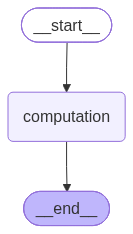

In [6]:
from IPython.display import Image, display
checkpointer=InMemorySaver()
graph=StateGraph(State)

graph.add_node("computation",computation)

graph.add_edge(START,"computation")
graph.add_edge("computation",END)

workflow=graph.compile(checkpointer=checkpointer)
display(Image(workflow.get_graph().draw_mermaid_png()))

In [7]:
initial_state = {
    "messages": [
        HumanMessage(content="what is the capital of india")
    ]
}

config = {
    "configurable": {
        "thread_id": "1"
    }
}

result = workflow.invoke(initial_state, config)

print(result["messages"][-1].content)

The capital of India is **New Delhi**.


In [8]:
# Interactive chat in Jupyter notebook
import ipywidgets as widgets

thread_id = '1'
conversation_output = widgets.Output()
input_box = widgets.Text(
    placeholder='Type your message (or "exit" to quit)',
    description='You:',
    style={'description_width': '50px'},
    layout=widgets.Layout(width='80%')
)
send_button = widgets.Button(description='Send', button_style='info')

def on_send_clicked(b):
    user_message = input_box.value.strip()
    
    if not user_message:
        return
    
    if user_message.lower() in ['exit', 'bye', 'quit']:
        with conversation_output:
            print("\nChat ended. Goodbye!")
        input_box.disabled = True
        send_button.disabled = True
        return
    
    with conversation_output:
        print(f"\nYou: {user_message}")
    
    try:
        config = {"configurable": {"thread_id": thread_id}}
        response = workflow.invoke({'messages': [HumanMessage(content=user_message)]}, config)
        ai_message = response['messages'][-1].content
        
        with conversation_output:
            print(f"AI: {ai_message}")
    except Exception as e:
        with conversation_output:
            print(f"Error: {e}")
    
    input_box.value = ''

send_button.on_click(on_send_clicked)

print("✓ Chat Interface Ready - Type your message and click Send (or type 'exit' to quit)")
display(widgets.HBox([input_box, send_button]))
display(conversation_output)

✓ Chat Interface Ready - Type your message and click Send (or type 'exit' to quit)


Output()